### Heating Rate Analysis
2026-07-28

Aim is to vastly simplify the current analysis of circa 2024 data.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
from scipy.optimize import curve_fit
from scipy.constants import h, hbar, pi, k as k_B

# paths
import sys
from pathlib import Path

notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
analysis_dir = parent_dir / "analysis"

if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

if str(analysis_dir) not in sys.path:
    sys.path.append(str(analysis_dir))

from analysis.constants import mK, abg_97, DeltaB_97, B0_97
from analysis.resonant_scattering import scattering_length
from field_wiggle_calibration import inv_a_amp_from_Vpp, Bamp_from_Vpp
from analysis.unitary_fermi_gas import TrappedUnitaryGas

In [62]:
def inv_a_amp_from_Bamp(B_eq, Bamp):
    """
    Calculate the inverse scattering length amplitude (delta inv_a) from the the magnetic field amplitude (Bamp).
    """
    inv_a_amp = np.abs(1/scattering_length(B_eq + Bamp, B0_97, DeltaB_97, abg_97) \
					   - 1/scattering_length(B_eq, B0_97, DeltaB_97, abg_97))

    return inv_a_amp


def saturation(x, a, b):
    """
    Saturation function for fitting.
    """
    return a * (1 - np.exp(-x/b))

In [47]:
### Load metadata dataframe
metadata_file = 'heating_metadata.xlsx'
metadata = pd.read_excel(metadata_file)

### Load data files
metadf =  metadata.loc[metadata['exclude'] == 0][['filename', 'B', 'barnu']]

data_folder = 'heating'

dfs = []
for row in metadf.itertuples(index=False):
    file = row.filename
    print(file)
    
    df = pd.read_table(os.path.join(data_folder, file + '.dat'), delimiter=',')
    df['filename'] = file
    df['B'] = row.B
    df['barnu'] = row.barnu
    dfs.append(df)

# Show columns
# for df in dfs:
    # print(df.filename[0])
    # print(df.columns)

dfs[3]['EFkHz'] = dfs[3]['EF'] / h / 1e3  # Add mimssing column

2024-03-19_L_UHfit
2024-03-21_B_UHfit
2024-03-21_D_UHfit
2024-03-26_B_UHfit
2024-03-26_C_UHfit
2024-04-03_E_UHfit
2024-04-03_F_UHfit
2024-04-04_C_UHfit
2024-04-05_C_UHfit
2024-04-10_C_UHfit
2024-04-10_D_UHfit
2024-05-09_M_UHfit
2024-05-10_R_UHfit
2024-05-10_S_UHfit


In [48]:
def fix_units(df):
    """
    Change all energy units in the dataframe to frequency.
    Specifically, it converts frequency from kHz to Hz and EF from J to Hz. 
    Also converts time from ms to s.
    """
    df['freq'] = df['freq'] * 1e3  # Convert kHz to Hz
    df['EF'] = df['EFkHz'] * 1e3  # Convert J to Hz
    df['time'] = df['time'] * 1e-3  # Convert ms to s
    df['wait_time'] = df['wait_time'] * 1e-3  # Convert ms to s
    df['E'] = df['EkHz'] * 1e3  # Convert kHz to Hz
    df['T'] = df['T'] * k_B / h  # Convert K to Hz
    
    return df

for df in dfs:
    df = fix_units(df)

In [49]:
def fit_two_points_linear(final, initial, y_name='T', x_name='time'):
    """
    Fit a linear model to two points and return the slope and intercept along with their uncertainties.
    Structured to be used in place of curve_fit when there are only two unique time points in the data.
    """
    # If there are only two unique time points, calculate the slope directly
    a = (final[y_name].mean() - initial[y_name].mean()) / (final[x_name].mean() - initial[x_name].mean())
    e_a = np.sqrt((final[y_name].sem()**2 + initial[y_name].sem()**2) / (final[x_name].mean() - initial[x_name].mean())**2)
    b = initial[y_name].mean() - a * initial[x_name].mean()
    e_b = np.sqrt(initial[y_name].sem()**2 + (e_a * initial[x_name].mean())**2)

    return [a, b], [e_a, e_b]  # popt, perr


def kF_from_EF(EF):
    """
    Calculate Fermi wavevector kF from Fermi energy EF (in Hz).
    """
    kF = np.sqrt(2 * mK * h * EF) / hbar
    return kF


def calculate_heating_rate(group):
    """
    Calculate heating rate from a dataframe containing time and temperature data.
    """

    total_time = group['time'].max() + group['wait_time'].min()
    group['kF'] = kF_from_EF(group['EF'])

    initial = group[group['time']==group['time'].min()]
    final = group[group['time']==group['time'].max()]

    num_time_pts = group['time'].nunique()

    if num_time_pts > 2:
        # Fit a linear model to the temperature vs time data
        popt, pcov = curve_fit(lambda t, a, b: a * t + b, 
                            group['time'], group['E'])
        perr = np.sqrt(np.diag(pcov)) 
    
    elif num_time_pts == 2:
        popt, perr = fit_two_points_linear(final, initial, y_name='E', x_name='time')

    raw_data = group[['time', 'E']].copy()
    
    return pd.Series({
                    'heating_rate': popt[0], 
                    'e_heating_rate': perr[0],
                    'Ei_fit': popt[1],
                    'e_Ei_fit': perr[1],
                    'B': initial['B'].mean(),
                    'barnu': initial['barnu'].mean(),
                    'Ei': initial['E'].mean(),
                    'e_Ei': initial['E'].sem(),
                    'Ef': final['E'].mean(),
                    'e_Ef': final['E'].sem(),
                    'kFi': initial['kF'].mean(),
                    'e_kFi': initial['kF'].sem(),
                    'kFf': final['kF'].mean(),
                    'e_kFf': final['kF'].sem(),
                    'Ti': initial['T'].mean(),
                    'e_Ti': initial['T'].sem(),
                    'Tf': final['T'].mean(),
                    'e_Tf': final['T'].sem(),
                    'EFi': initial['EF'].mean(),
                    'e_EFi': initial['EF'].sem(),
                    'EFf': final['EF'].mean(),
                    'e_EFf': final['EF'].sem(),
                    'ToTFi': initial['ToTF'].mean(),
                    'e_ToTFi': initial['ToTF'].sem(),
                    'ToTFf': final['ToTF'].mean(),
                    'e_ToTFf': final['ToTF'].sem(),
                    'total_time': total_time,
                    'data_points': len(group),
                    'num_time_pts': num_time_pts,
                    'raw_data': raw_data
                    })

results_list = [df.groupby(['freq', 'amplitude', 'filename']).apply(calculate_heating_rate) for df in dfs]

results_df = pd.concat(results_list, axis=0).reset_index()

results_df['Bamp'], _ = Bamp_from_Vpp(results_df['amplitude'], results_df['freq'])
results_df['inv_a_amp'] = inv_a_amp_from_Vpp(results_df['B'], results_df['amplitude'], results_df['freq'])
results_df['lambda_T'] = np.sqrt(hbar/(mK*results_df['Ti']))  # Assumes T is in Hz

results_df['inv_kFa'] = 1 / results_df['kFi'].mean() * results_df['inv_a_amp'].mean()
results_df['e_inv_kFa'] = results_df['inv_kFa'] * np.sqrt((results_df['kFi'].sem()/results_df['kFi'].mean())**2 \
                                  + (results_df['inv_a_amp'].sem()/results_df['inv_a_amp'].mean())**2)

results_df['A'] = results_df['lambda_T'] * results_df['inv_a_amp']
results_df['e_A'] = results_df['A'] * np.sqrt((results_df['lambda_T'].sem()/results_df['lambda_T'].mean())**2 \
                                  + (results_df['inv_a_amp'].sem()/results_df['inv_a_amp'].mean())**2)

results_df['delta_T'] = results_df['Tf'] - results_df['Ti']
results_df['e_delta_T'] = np.sqrt(results_df['e_Tf']**2 + results_df['e_Ti']**2)
results_df['delta_T_over_T'] = results_df['delta_T'] / results_df['Ti']
results_df['e_delta_T_over_T'] = results_df['e_delta_T'] / results_df['Ti']  # This is close but not fully accurate

results_df['delta_E'] = results_df['Ef'] - results_df['Ei']
results_df['e_delta_E'] = np.sqrt(results_df['e_Ef']**2 + results_df['e_Ei']**2)
results_df['delta_E_over_E'] = results_df['delta_E'] / results_df['Ei']
results_df['e_delta_E_over_E'] = results_df['e_delta_E'] / results_df['Ei']  # This is close but not fully accurate

# Calculate heating rate with ampiltude removed for comparison
results_df['norm_heating_rate'] = results_df['heating_rate'] / results_df.A**2
results_df['e_norm_heating_rate'] = results_df['norm_heating_rate'] * np.sqrt((results_df['e_heating_rate']/results_df['heating_rate'])**2 \
                                                + (2*results_df.e_A/results_df.A)**2)

In [50]:
results_df[['freq', 'Bamp', 'heating_rate', 'Ti', 'Tf', 'EFi', 'num_time_pts']]

,freq,Bamp,heating_rate,Ti,Tf,EFi,num_time_pts
0,5000.0,0.078024,49237.165634,8679.009244,8779.983501,15592.250000,11
1,20000.0,0.058975,426899.681751,8663.699539,10222.403669,15015.450000,11
2,40000.0,0.039927,494571.099399,8738.596766,10329.050694,15591.150000,11
3,15000.0,0.063737,305317.426797,8425.328616,9353.214520,14959.875000,11
4,35000.0,0.035165,348730.225745,8494.542655,9491.470697,15102.850000,11
...,...,...,...,...,...,...,...
74,7000.0,0.163740,296665.665666,8856.977934,9806.533922,16874.850000,2
75,9000.0,0.163740,536816.816817,8657.867369,10391.624104,16778.150000,2
76,11000.0,0.087548,288638.638639,8893.915009,9801.816512,17026.110000,2
77,30000.0,0.049451,494822.822823,8870.380047,10486.174430,16872.980000,2


### Colour plot all data

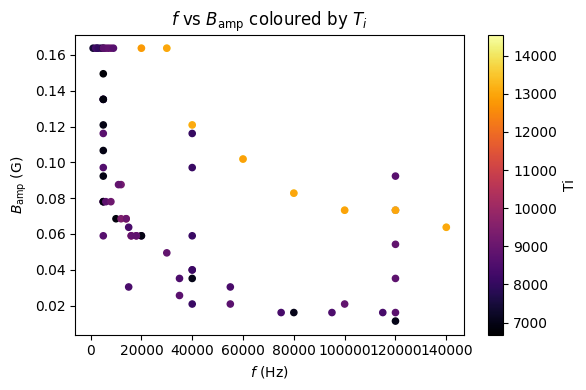

In [51]:
import matplotlib.pyplot as plt

# Create the scatter plot
scatter = results_df.plot.scatter(
    x='freq', 
    y='Bamp', 
    c='Ti', 
    cmap='inferno', 
    colorbar=True,   # Shows the color scale bar on the right
    figsize=(6, 4),
    sharex=False,     # Fixes a common matplotlib bug with x-axis labels
)

# Label the chart
scatter.set_title(r'$f$ vs $B_\mathrm{amp}$ coloured by $T_i$')
scatter.set_xlabel(r'$f$ (Hz)')
scatter.set_ylabel(r'$B_\mathrm{amp}$ (G)')

plt.tight_layout()  # Adjust subplots to fit into figure area.

plt.show()


### Check linear time scaling

In [52]:
df = results_df.copy()
df_filtered = df[df['num_time_pts'] > 2].sort_values(by='freq', 
                    ascending=True, ignore_index=True)

df_filtered[['filename', 'freq', 'Bamp', 'heating_rate', 'Ti', 'Tf', 'EFi', 'num_time_pts', 'ToTFi']]

,filename,freq,Bamp,heating_rate,Ti,Tf,EFi,num_time_pts,ToTFi
0,2024-03-19_L_UHfit,5000.0,0.078024,49237.165634,8679.009244,8779.983501,15592.250000,11,0.556812
1,2024-03-21_B_UHfit,15000.0,0.063737,305317.426797,8425.328616,9353.214520,14959.875000,11,0.563509
2,2024-03-21_D_UHfit,15000.0,0.030403,94039.039317,8427.787337,8950.025940,16074.350000,11,0.524413
3,2024-03-19_L_UHfit,20000.0,0.058975,426899.681751,8663.699539,10222.403669,15015.450000,11,0.577516
4,2024-03-21_B_UHfit,35000.0,0.035165,348730.225745,8494.542655,9491.470697,15102.850000,11,0.562461
5,2024-03-21_D_UHfit,35000.0,0.025641,246030.720025,8735.530310,9476.577724,16466.700000,11,0.530556
6,2024-03-19_L_UHfit,40000.0,0.039927,494571.099399,8738.596766,10329.050694,15591.150000,11,0.560882
7,2024-03-21_B_UHfit,55000.0,0.030403,436579.693150,8372.080636,9808.083125,15453.200000,11,0.541959
8,2024-03-21_D_UHfit,55000.0,0.020879,274485.444868,8729.772458,9750.631357,15974.000000,11,0.546509
9,2024-03-21_B_UHfit,75000.0,0.016117,226149.579879,8361.575507,9174.056060,15046.133333,11,0.555921


In [53]:
drop_index = [2, 4, 7]
df_plot = df_filtered.drop(index=drop_index)

print(df_plot.ToTFi.mean(), df_plot.ToTFi.std())
print(df_plot.EFi.mean(), df_plot.EFi.std())

0.5568747777777777 0.013031741308750483
15413.03425925926 533.1167390828724


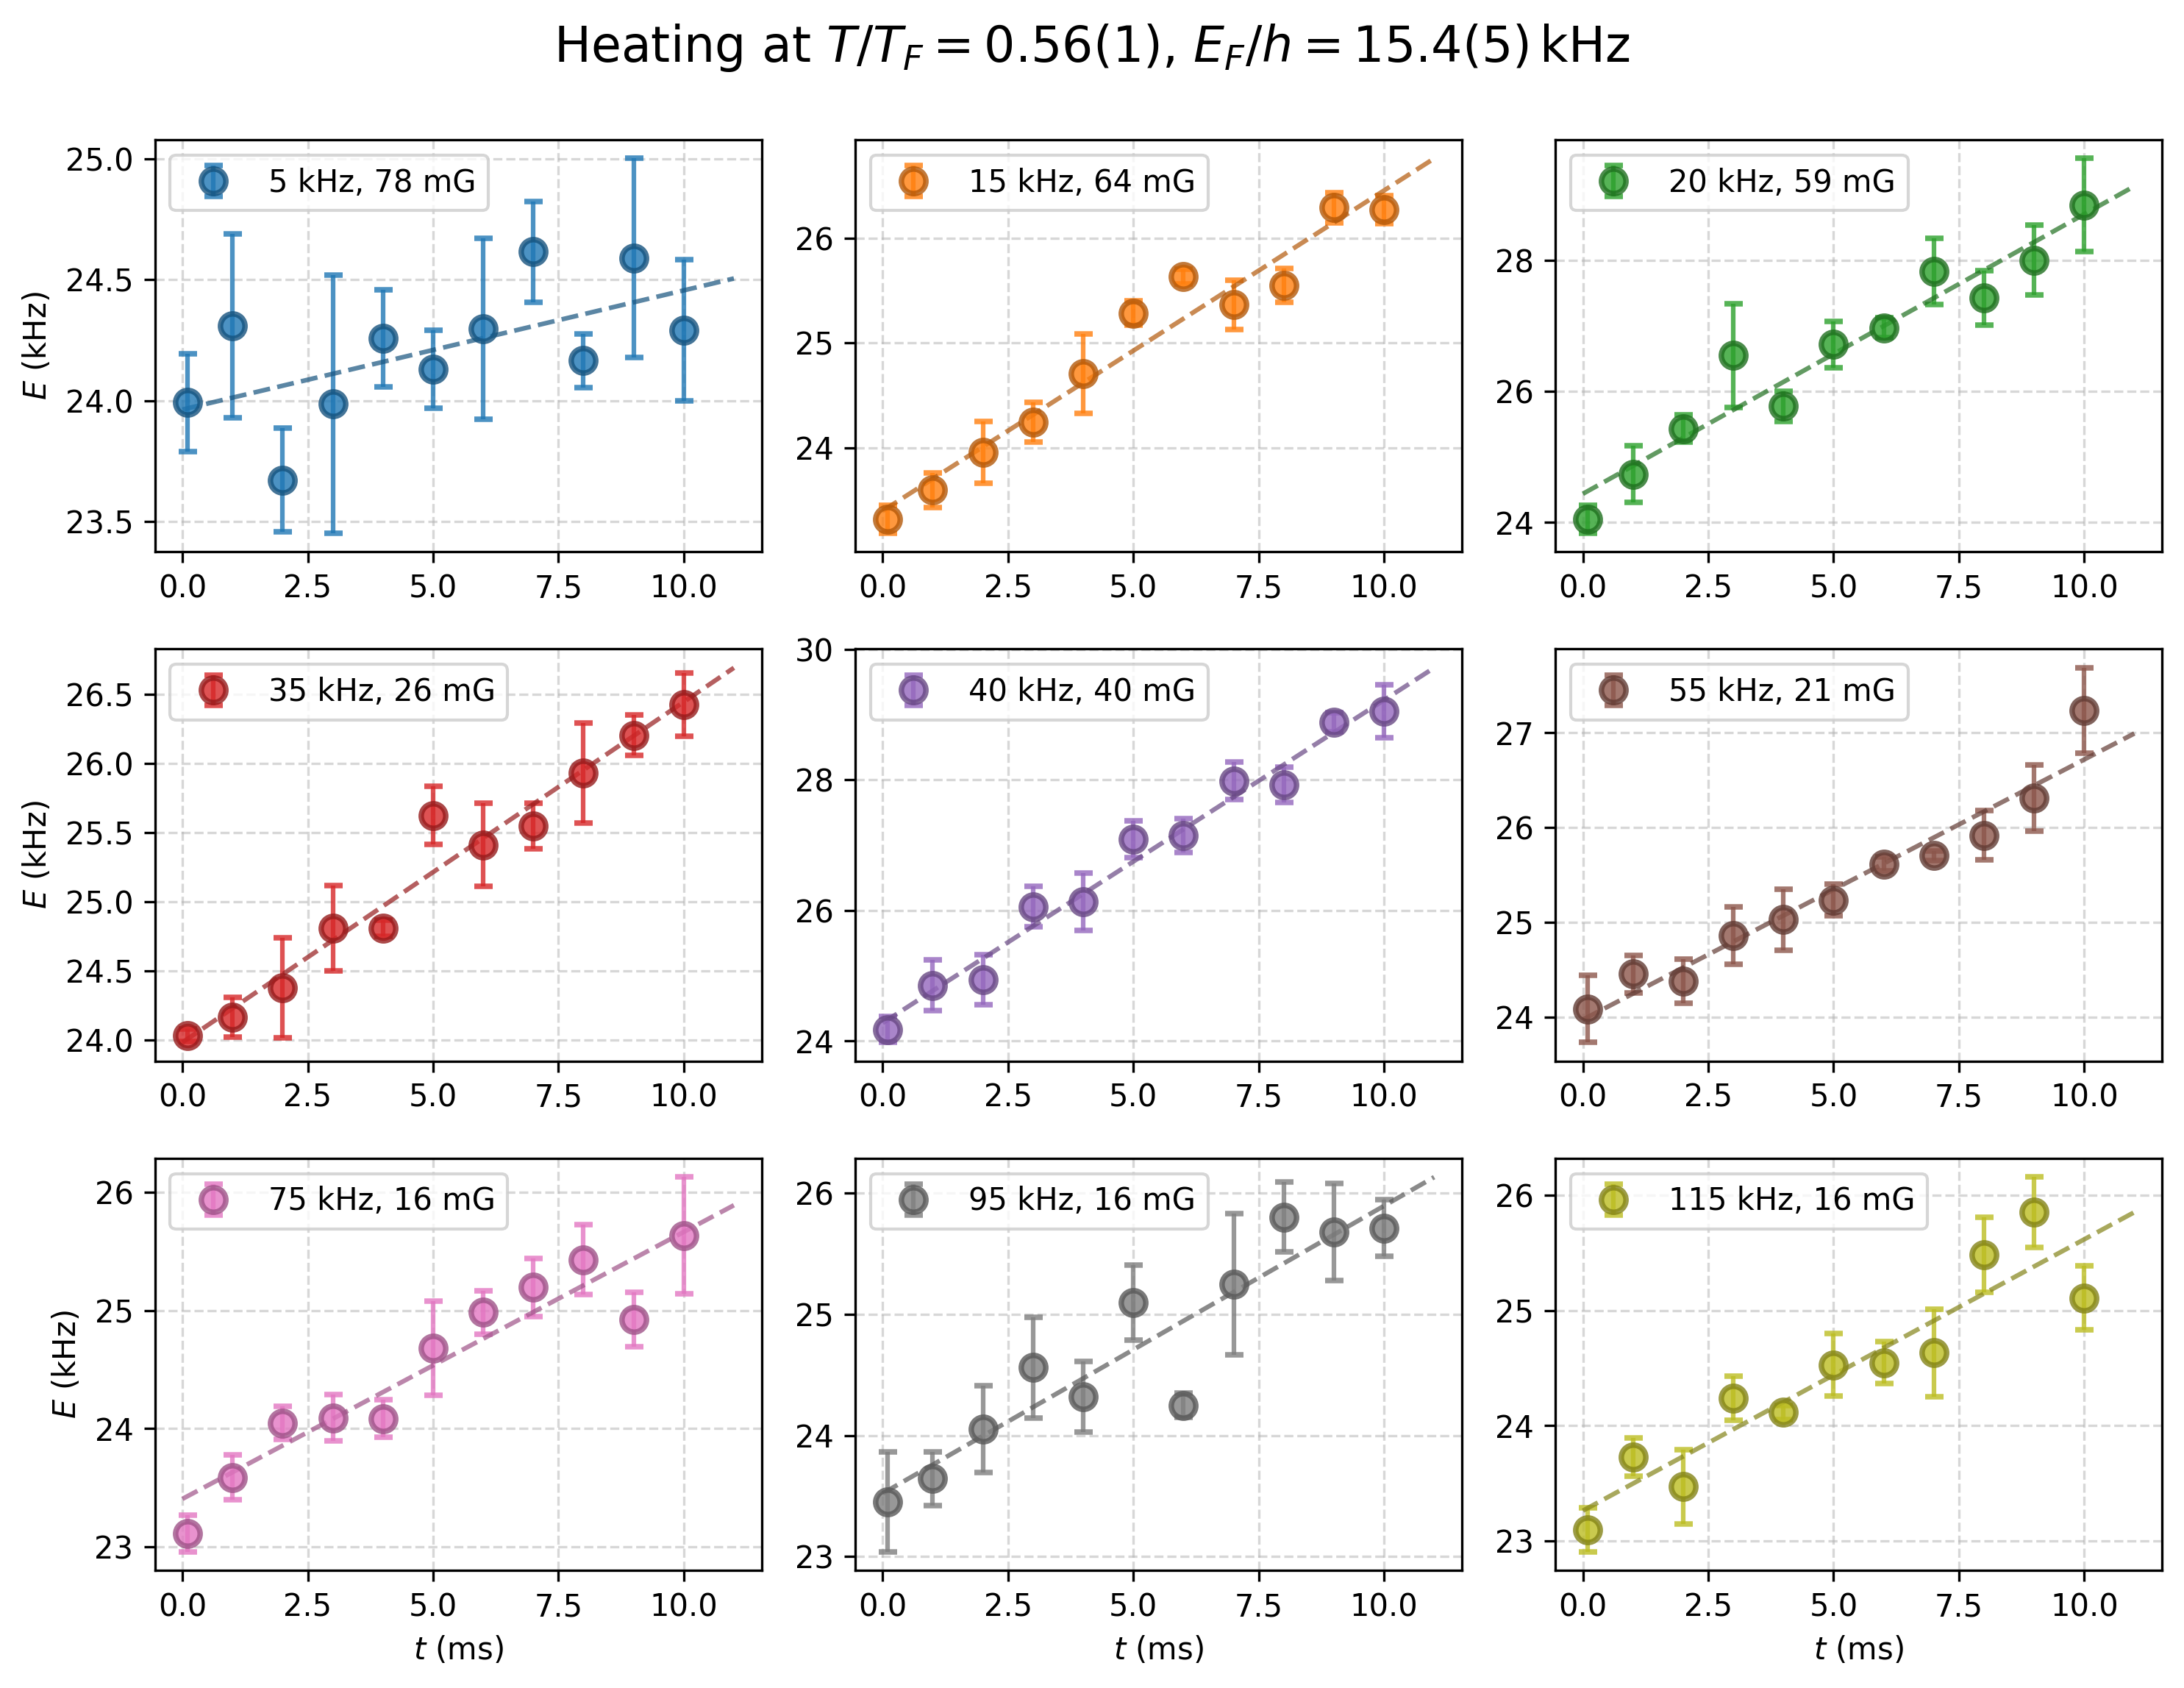

In [54]:
# Plot each frequency group individually to assign distinct colors
fig, axes = plt.subplots(3, 3, figsize=(10, 8), dpi=300)
axs = axes.flatten()  
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = 2*colors

fig.suptitle(r'Heating at $T/T_F = 0.56(1)$, $E_F/h=15.4(5)\,$kHz', fontsize=16, y=0.95)

for i, row in enumerate(df_plot.itertuples(index=False)):
    # print(row)
    ax = axs[i]

    trapped_gas_params = (row.ToTFi, row.EFi, row.barnu)

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it

    data = row.raw_data.groupby('time', as_index=False).agg(
                                    E_mean=('E', 'mean'),
                                    E_sem=('E', 'sem')
                                )
    
    ax.errorbar(
        x=data['time']*1e3,  # ms
        y=data['E_mean']/1e3,    # kHz
        yerr=data['E_sem']/1e3,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,             # Controls marker size
        label=f'{row.freq/1e3:.0f} kHz, {row.Bamp*1e3:.0f} mG'    # Add a label for the legend
    )

    ts = np.linspace(0, row.total_time, 100)
    ax.plot(ts*1e3, row.heating_rate*ts/1e3 + row.Ei_fit/1e3, 
            color=dark_edge_color, linestyle='--', alpha=0.7)

    if i in [6, 7, 8]:  # Only label the bottom row
        ax.set_xlabel(r'$t$ (ms)')
    if i in [0, 3, 6]:  # Only label the leftmost column
        ax.set_ylabel(r'$E$ (kHz)')
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()


fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Compare N>2 datasets to theory

In [55]:
drop_index = [4]
df_plot = df_filtered.drop(index=drop_index)

print(df_plot.ToTFi.mean(), df_plot.ToTFi.std())
print(df_plot.EFi.mean(), df_plot.EFi.std())

df_plot['A']

0.5525677499999998 0.015591006595550506
15476.805303030304 516.5196268626621


0     0.560300
1     0.463572
2     0.220016
3     0.422699
5     0.182131
6     0.284149
7     0.220747
8     0.148251
9     0.116850
10    0.116121
11    0.116889
Name: A, dtype: float64

c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:395: RuntimeWarning: invalid value encountered in divide
  self.zetaDrude = self.Edot_drude/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:396: RuntimeWarning: divide by zero encountered in divide
  self.zetaC = self.Edot_contact/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)
C:\Users\coldatoms\AppData\Local\Temp\ipykernel_20276\2826654567.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[

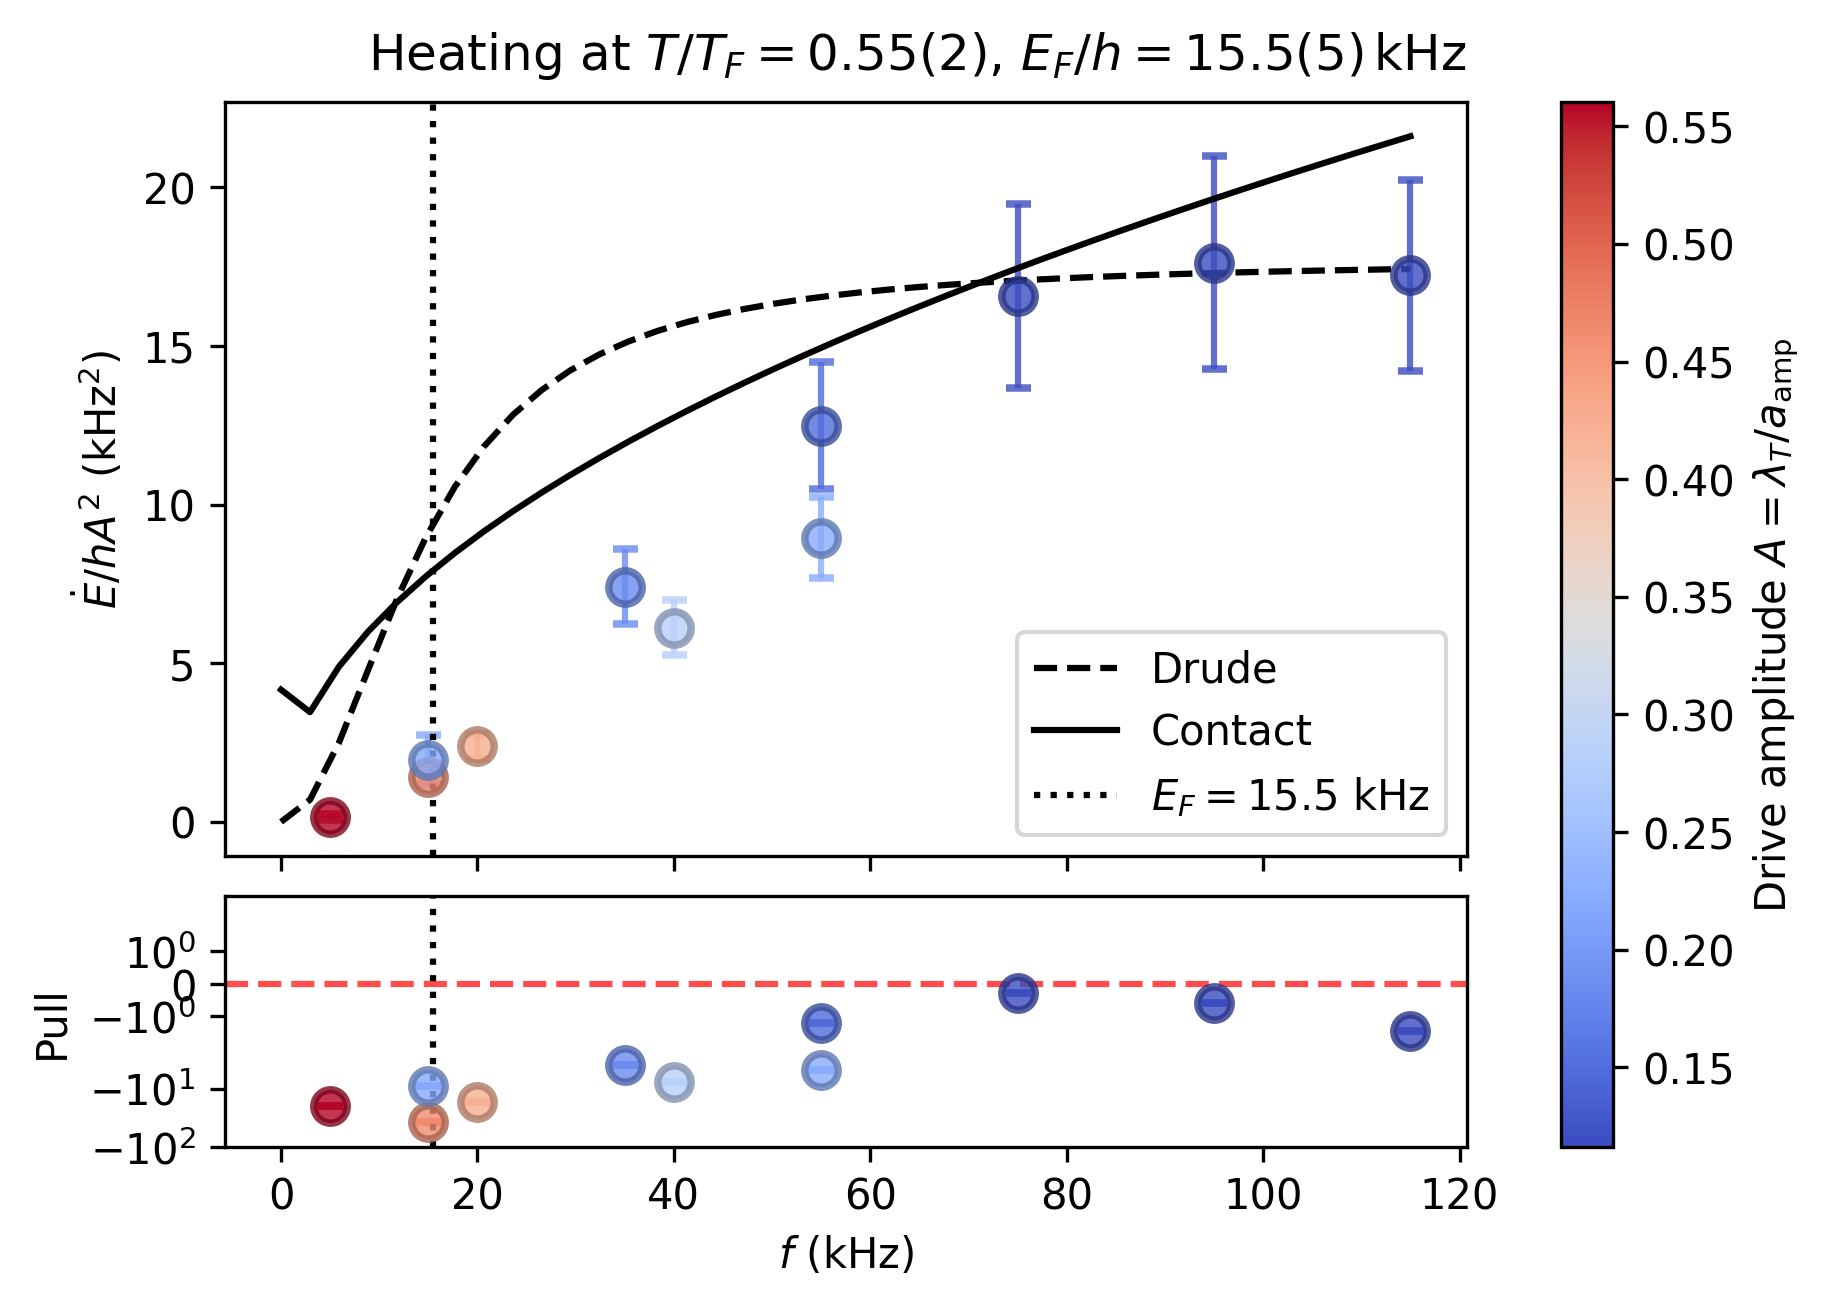

In [56]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

trapped_gas_params = (df_plot.ToTFi.mean(), df_plot.EFi.mean(), df_plot.barnu.mean())
TUG = TrappedUnitaryGas(*trapped_gas_params)
TUG.modulate_field(np.linspace(0, df_plot.freq.max(), 40))


df_plot['x'] = df_plot.freq/1e3  # kHz
df_plot['y'] = df_plot['norm_heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_norm_heating_rate']/1e6  # kHz^2
df_plot['Edot_th'] = np.interp(df_plot.freq, TUG.nus, TUG.Edot/TUG.Ns/2)
df_plot['y_th'] = df_plot['Edot_th']/1e6  # kHz^2
df_plot['res'] = df_plot['y'] - df_plot['y_th']
df_plot['dev'] = df_plot['res'] / df_plot['y_th'] * 100  # Percent deviation
df_plot['e_dev'] = df_plot['yerr'] / df_plot['y_th'] * 100  # Percent deviation error
df_plot['pull'] = (df_plot['y'] - df_plot['y_th'])/df_plot['yerr']  # Pull value


# Define drive amplitide color mapping
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['A'].min(), vmax=df_plot['A'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.A))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-100, 5))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Drive amplitude $A = \lambda_T/a_\mathrm{amp}$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

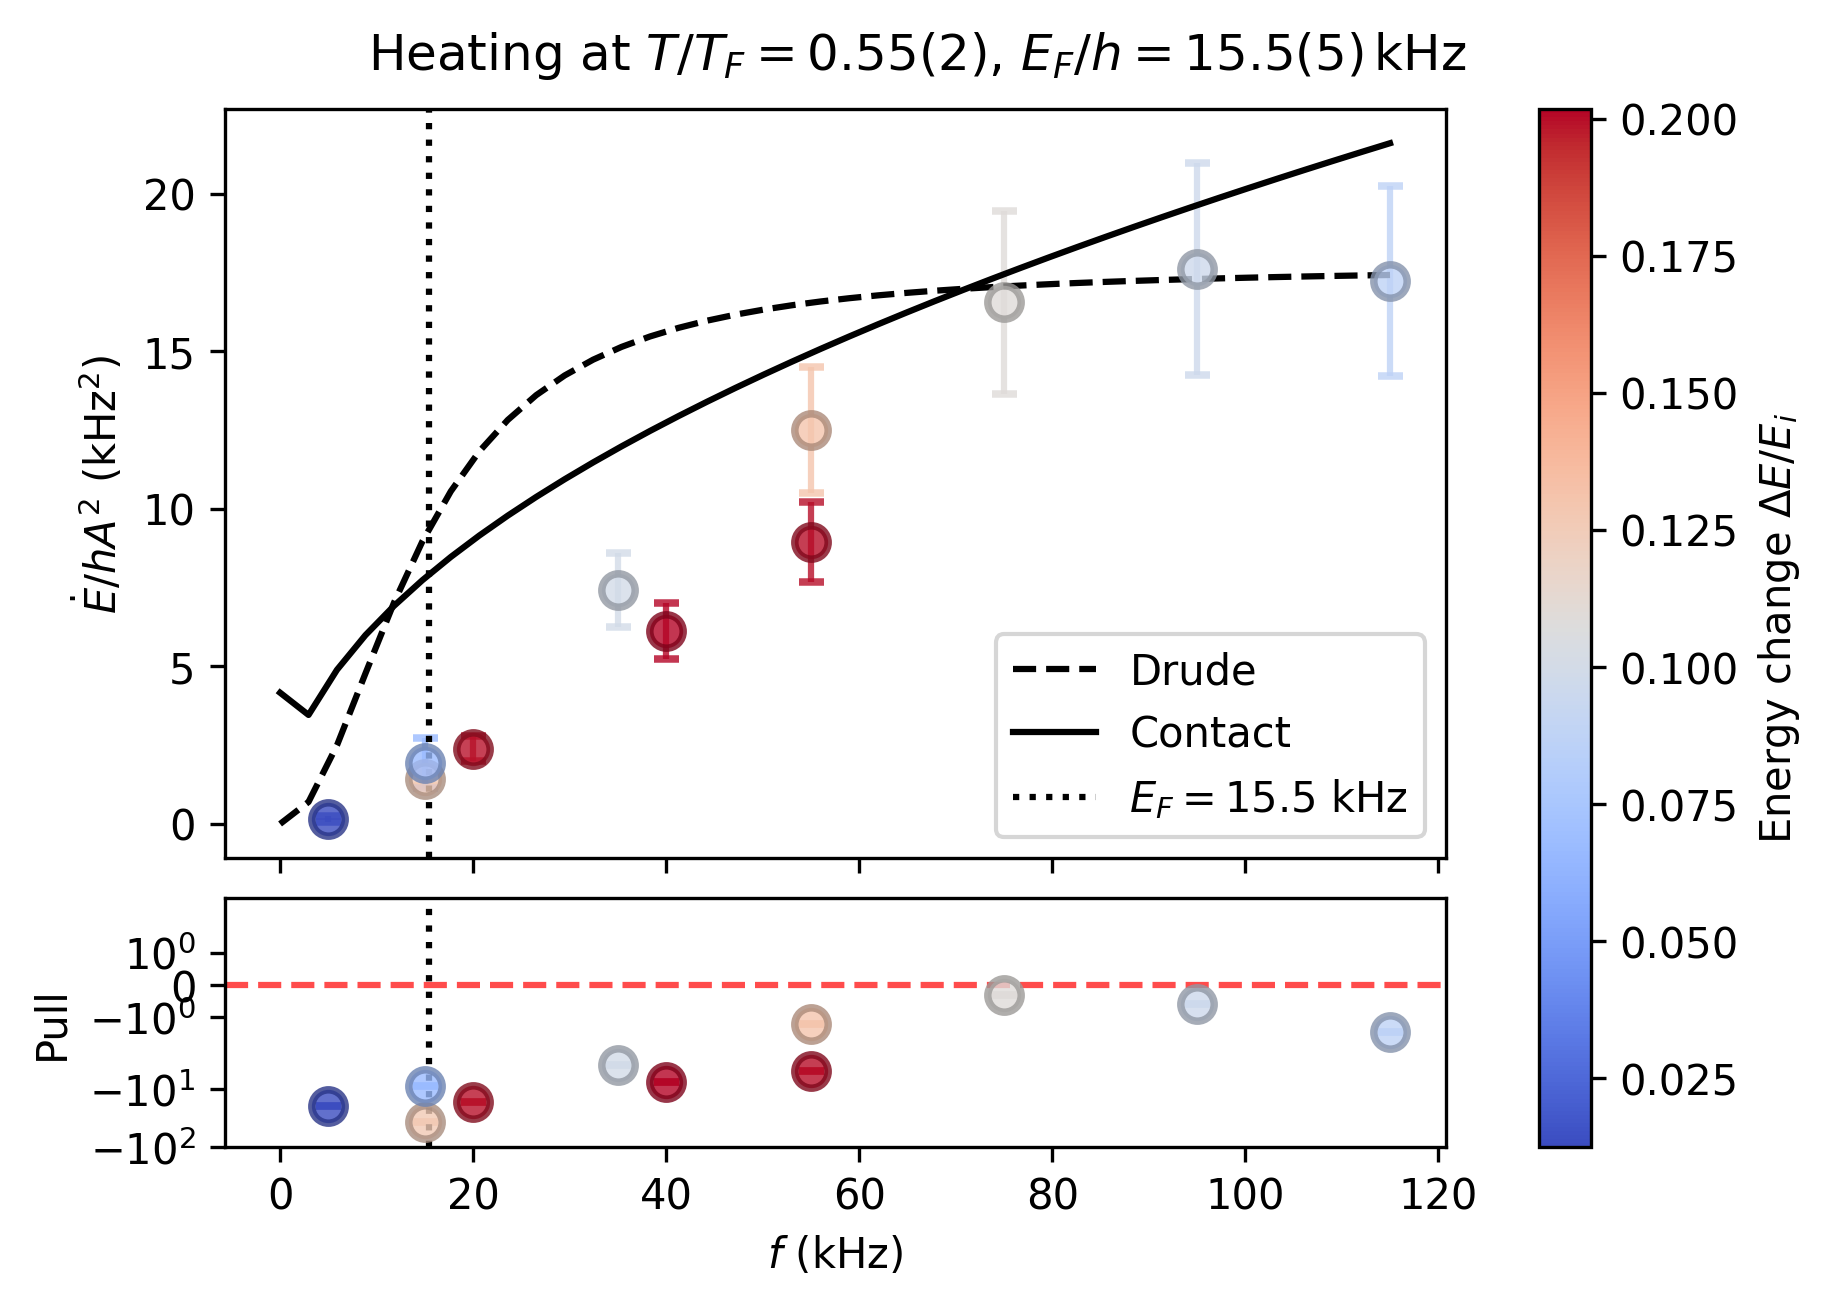

In [57]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

# Define change in temperature color mapping
# cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['delta_E_over_E'].min(), 
                         vmax=df_plot['delta_E_over_E'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.delta_E_over_E))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-100, 5))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Energy change $\Delta E/E_i$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

### Checking amplitude scaling 
**Runs:** \
2024-03-26_B_UHfit.dat \
2024-03-26_C_UHfit.dat \
2024-04-03_F_UHfit.dat \
2024-04-05_C_UHfit.dat

In [58]:
df = results_df.copy()

# Find the 3 most common frequencies
top_3_freqs = df['freq'].value_counts().nlargest(3).index

# Filter the DataFrame to keep only those 3 frequencies
df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]

# These are datasets where the initial temperature is too different from most of the others
drop_index = [73, 12, 29, 2, 47, 55, 31, 51, 59, 26]
df_plot = df_filtered.drop(index=drop_index)

C:\Users\coldatoms\AppData\Local\Temp\ipykernel_20276\4017541092.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]


In [59]:
df_plot[['filename', 'freq', 'Bamp', 'norm_heating_rate', 'Ti', 'Tf', 'EFi', 'num_time_pts', 'ToTFi']]

,filename,freq,Bamp,norm_heating_rate,Ti,Tf,EFi,num_time_pts,ToTFi
13,2024-03-26_B_UHfit,40000.0,0.039927,5.465574e+06,8146.851368,9669.983222,15665.261256,2,0.520546
14,2024-03-26_B_UHfit,40000.0,0.058975,4.852480e+06,8097.024761,9584.186360,15865.210844,2,0.510655
15,2024-03-26_B_UHfit,40000.0,0.097072,3.935707e+06,8121.005626,9790.637666,15806.458071,2,0.514064
16,2024-03-26_B_UHfit,40000.0,0.116120,3.603201e+06,8044.312282,10266.577301,15676.457938,2,0.513450
18,2024-03-26_C_UHfit,5000.0,0.078024,1.674439e+05,8659.734330,8818.780244,14927.160000,2,0.580904
22,2024-03-26_C_UHfit,120000.0,0.016117,2.247249e+07,8725.015458,9657.918820,14767.540000,2,0.591550
23,2024-03-26_C_UHfit,120000.0,0.035165,1.160420e+07,8780.119981,9683.239480,14616.060000,2,0.601899
24,2024-03-26_C_UHfit,120000.0,0.054213,8.414571e+06,8877.729123,9638.146952,14305.240000,2,0.622894
25,2024-03-26_C_UHfit,120000.0,0.073261,7.108779e+06,8839.287644,9446.281280,14585.800000,2,0.607121
34,2024-04-03_F_UHfit,5000.0,0.135168,6.146550e+04,7589.539526,8437.508141,12727.087500,2,0.598007


c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:369: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, _ = quad(lambda v: weight_func(v, self.betabaromega) \
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:395: RuntimeWarn

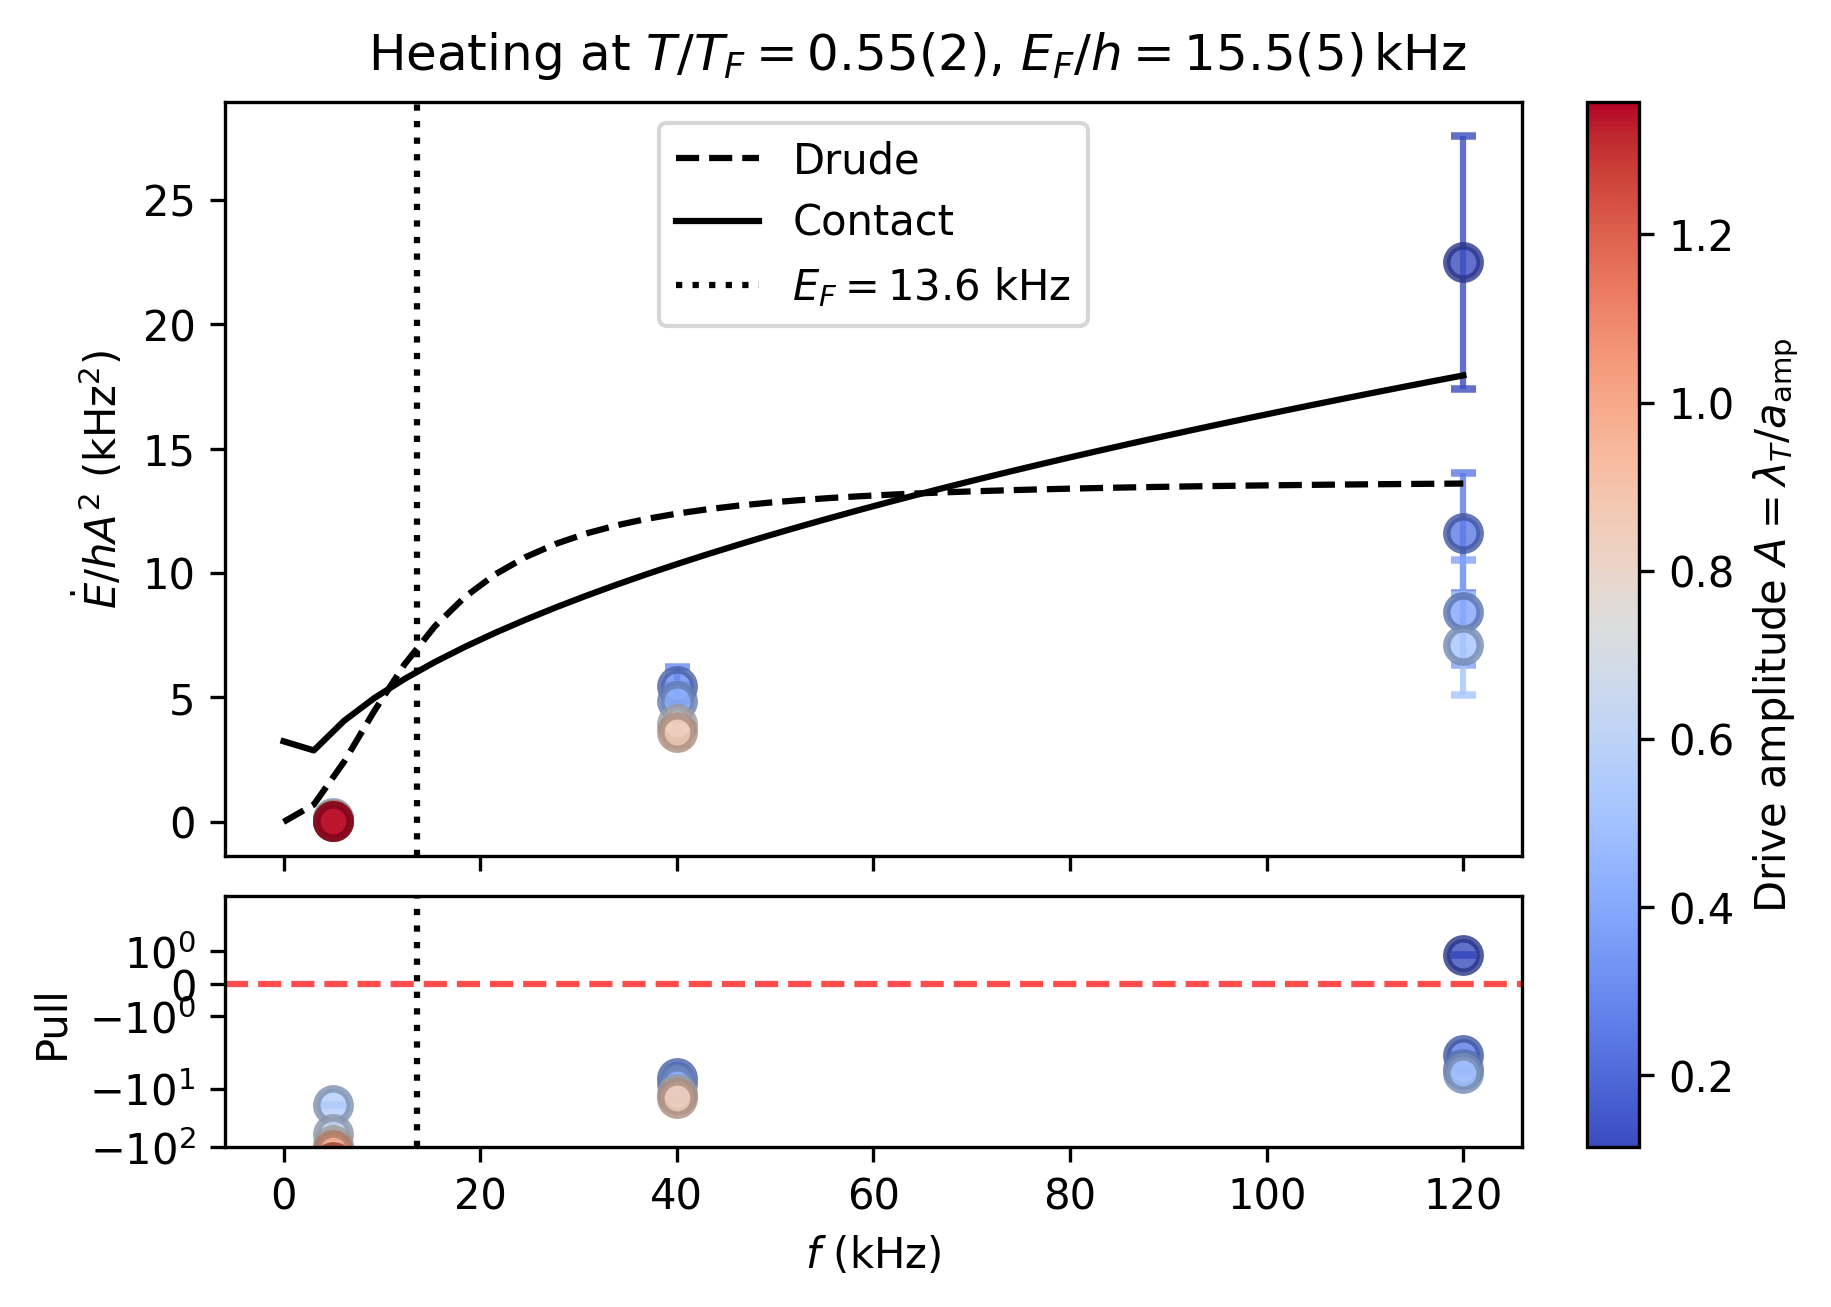

In [60]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

trapped_gas_params = (df_plot.ToTFi.mean(), df_plot.EFi.mean(), df_plot.barnu.mean())
TUG = TrappedUnitaryGas(*trapped_gas_params)
TUG.modulate_field(np.linspace(0, df_plot.freq.max(), 40))


df_plot['x'] = df_plot.freq/1e3  # kHz
df_plot['y'] = df_plot['norm_heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_norm_heating_rate']/1e6  # kHz^2
df_plot['Edot_th'] = np.interp(df_plot.freq, TUG.nus, TUG.Edot/TUG.Ns/2)
df_plot['y_th'] = df_plot['Edot_th']/1e6  # kHz^2
df_plot['res'] = df_plot['y'] - df_plot['y_th']
df_plot['dev'] = df_plot['res'] / df_plot['y_th'] * 100  # Percent deviation
df_plot['e_dev'] = df_plot['yerr'] / df_plot['y_th'] * 100  # Percent deviation error
df_plot['pull'] = (df_plot['y'] - df_plot['y_th'])/df_plot['yerr']  # Pull value


# Define drive amplitide color mapping
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['A'].min(), vmax=df_plot['A'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.A))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-100, 5))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Drive amplitude $A = \lambda_T/a_\mathrm{amp}$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

Quadratic fits for each frequency:
-------------------------------------
0.5880134570987654 12210.925401234568 292.9299812814759
Frequency: 5000.0 Hz, Fit slope: -0.0098 ± 0.0087, Intercept: 0.064595 ± 0.011921
0.9782776956137592
0.514678525 15753.34702727227 323.2660771177012
Frequency: 40000.0 Hz, Fit slope: -2.5612 ± 0.4126, Intercept: 5.447551 ± 0.225893


c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)


1.1624219250572514
0.6058659 14568.66 323.2660771177012
Frequency: 120000.0 Hz, Fit slope: -30.8043 ± 18.0634, Intercept: 14.569346 ± 3.371637
0.9373497665863288


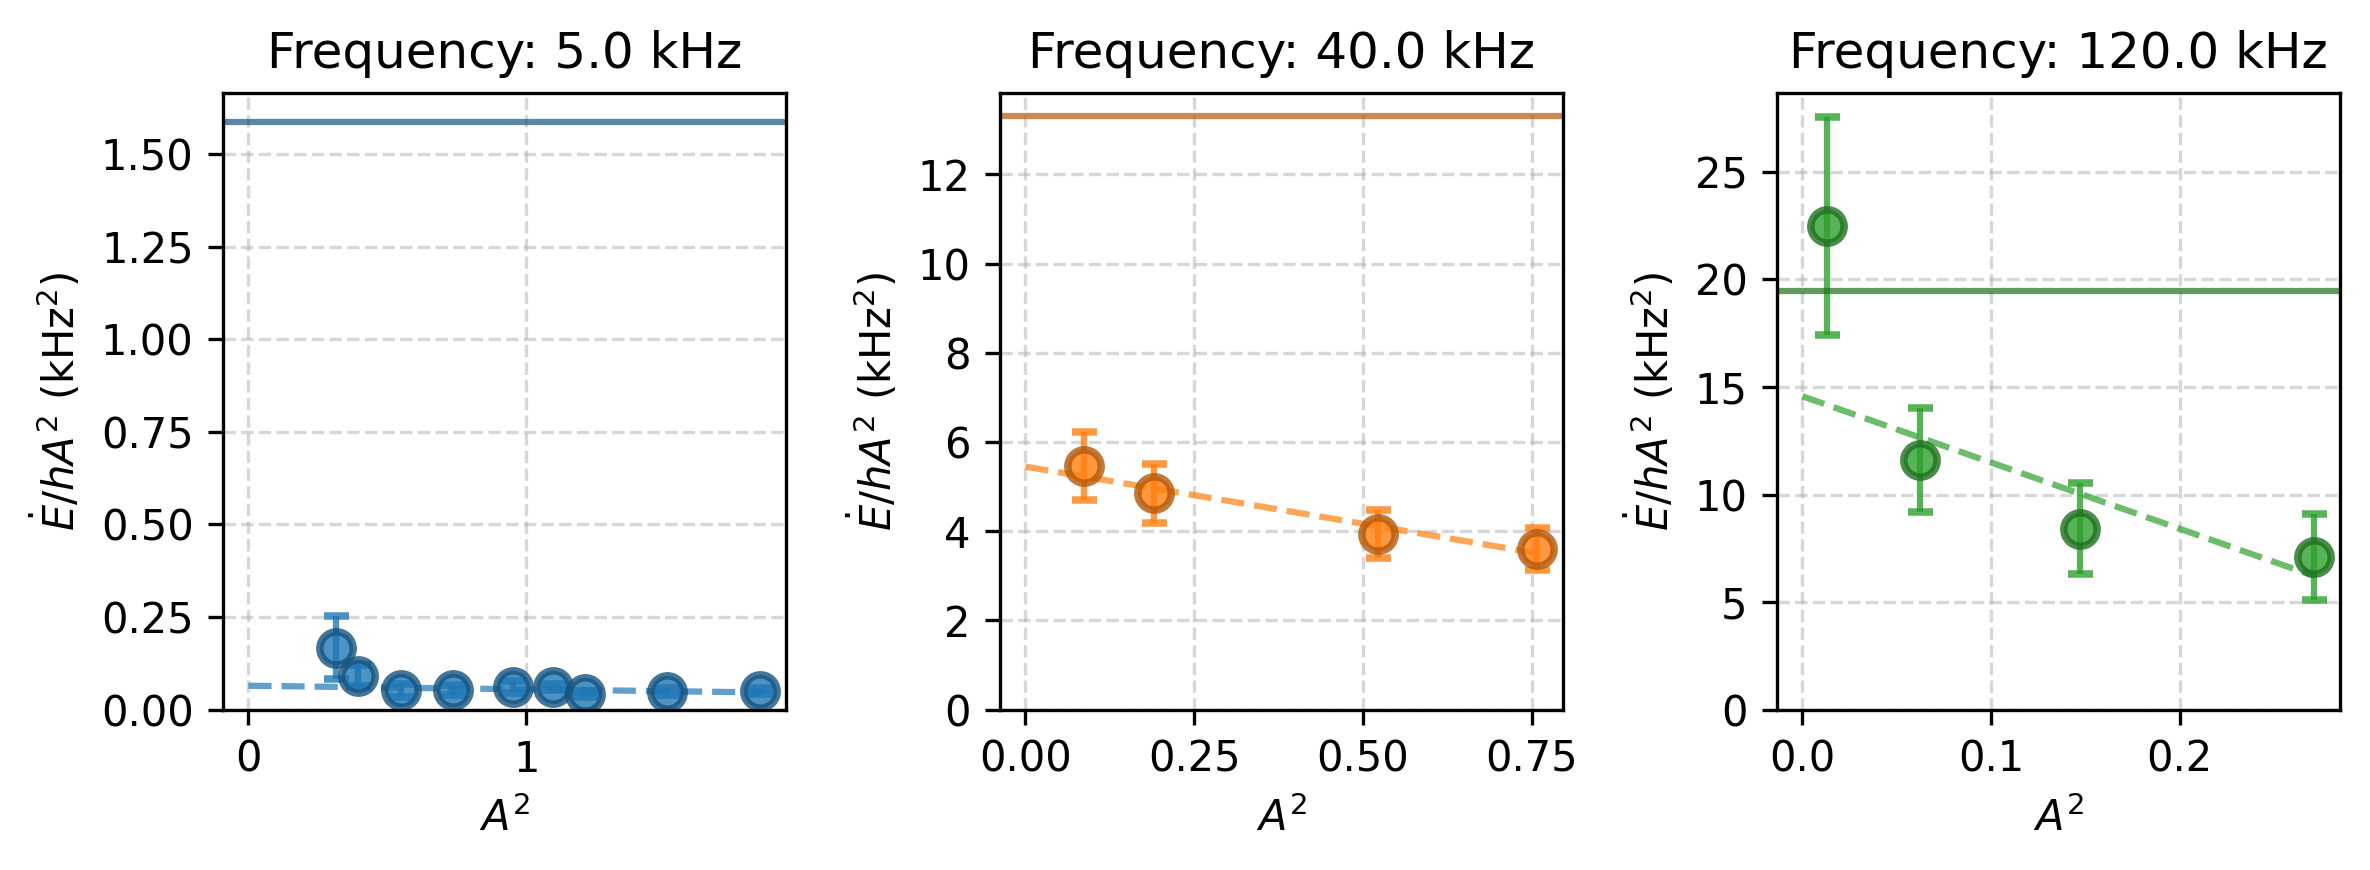

In [61]:
# Set font size back to default
plt.rcParams.update({'font.size': 10})

# Plot each frequency group individually to assign distinct colors
fig, axes = plt.subplots(1, 3, figsize=(8, 3), dpi=300)
axs = axes.flatten()  
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

print("Quadratic fits for each frequency:")
print("-------------------------------------")

for i, freq_val in enumerate(top_3_freqs):
    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val].copy()
    trapped_gas_params = (group['ToTFi'].mean(), group['EFi'].mean(), group['barnu'].mean())

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    axs[i].errorbar(
        x=group['A']**2,
        y=group['norm_heating_rate']/1e6,    # kHz^2
        yerr=group['e_norm_heating_rate']/1e6,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,                      # Controls marker size
        label=f'{freq_val} Hz'     # Add a label for the legend
    )

    popt, pcov = curve_fit(lambda x, m, b: m * x + b,
                            group['A']**2, 
                            group['norm_heating_rate']/1e6,  # kHz^2
                            sigma=group['e_norm_heating_rate']/1e6
                           )
    perr = np.sqrt(np.diag(pcov))

    print(*trapped_gas_params)
    print(f"Frequency: {freq_val} Hz, Fit slope: {popt[0]:.4f} ± {perr[0]:.4f}, Intercept: {popt[1]:.6f} ± {perr[1]:.6f}")

    TUG = TrappedUnitaryGas(*trapped_gas_params)
    print(TUG.Ctrap)

    a_sqs = np.linspace(0, group['A'].max()**2, 100)
    inv_as = inv_a_amp_from_Bamp(group['B'].mean(), np.sqrt(a_sqs))

    axs[i].plot(a_sqs, np.polyval(popt, a_sqs), color=colors[i], linestyle='--', alpha=0.7)
    # axs[i].plot(a_sqs, np.array([TUG.calc_Edot(nu=freq_val, inv_a0=inv_a) for inv_a in inv_as])/1e6/TUG.Ns/2, 
    #             color=dark_edge_color, linestyle=':', alpha=0.7)
    axs[i].axhline(y=TUG.calc_Edot(nu=freq_val)/1e6/TUG.Ns/2, color=dark_edge_color, linestyle='-', alpha=0.7)


# Label the chart
for ax in axs:
    ax.set_title(f'Frequency: {top_3_freqs[axs.tolist().index(ax)]/1e3} kHz')
    ax.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')
    ax.set_xlabel(r'$A^2$')
    ax.grid(True, linestyle='--', alpha=0.5)
    # ax.legend(title='Frequencies', loc='lower right')
    _, top = ax.get_ylim()
    ax.set_ylim(bottom=0, top=top)

fig.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()


0.5880134570987654 12210.925401234568 292.9299812814759
f: 5000.0 Hz, Edot_sat: 0.1672 ± 0.0930, A^2_sat: 2.382671 ± 1.778827
0.514678525 15753.34702727227 323.2660771177012
f: 40000.0 Hz, Edot_sat: 4.3524 ± 0.3666, A^2_sat: 0.782299 ± 0.089642
0.6058659 14568.66 323.2660771177012
f: 120000.0 Hz, Edot_sat: 1.5255 ± 0.4931, A^2_sat: 0.078893 ± 0.040574


C:\Users\coldatoms\AppData\Local\Temp\ipykernel_20276\2085537697.py:88: UserWarning: The figure layout has changed to tight
  fig.tight_layout()  # Adjust subplots to fit into figure area.


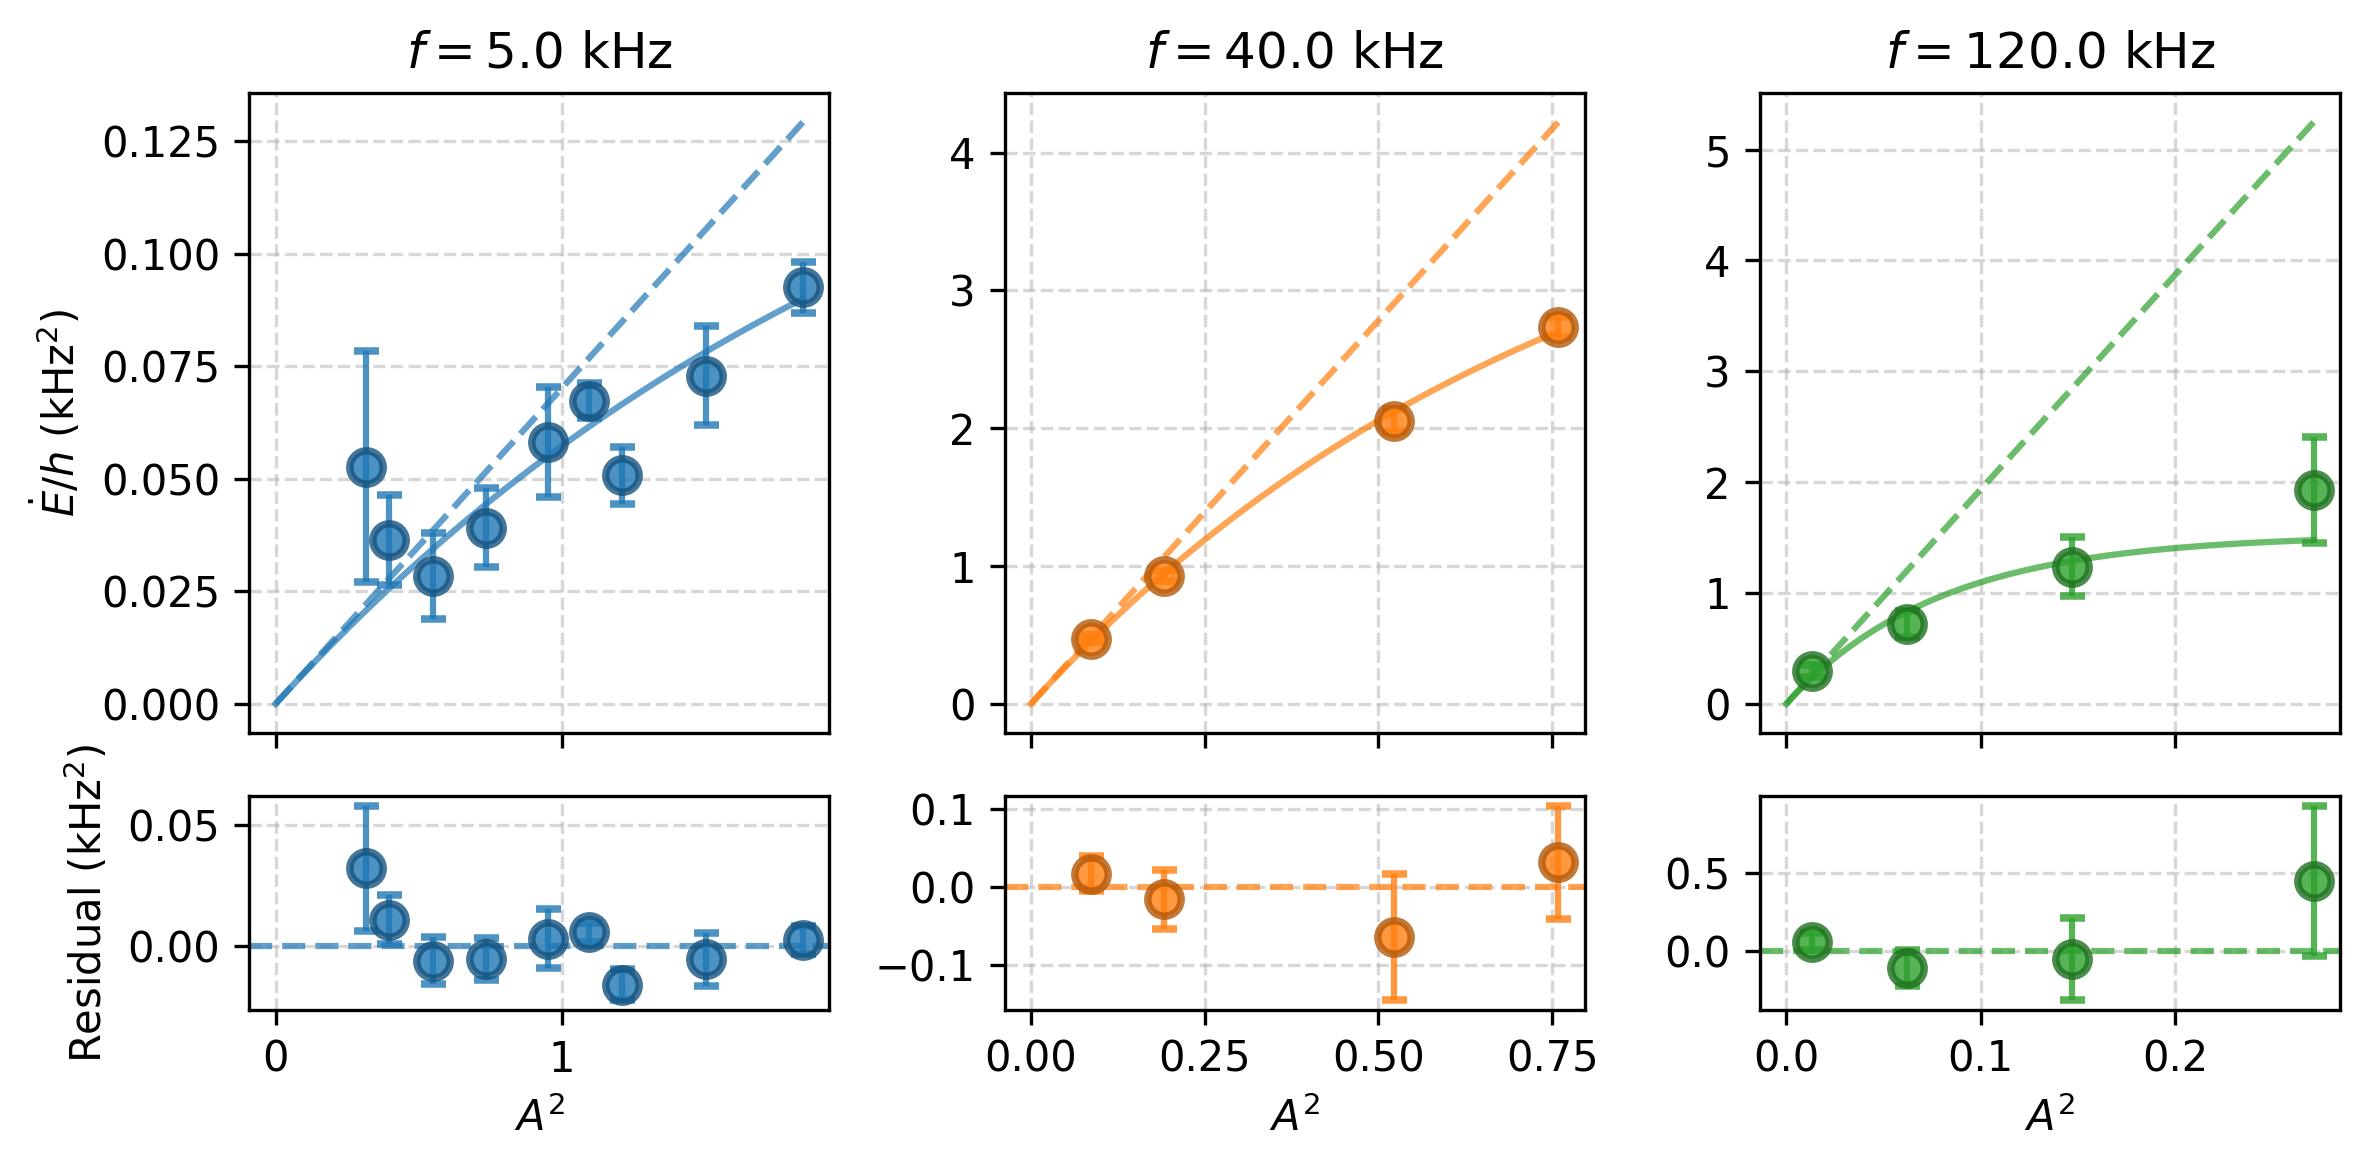

In [ ]:
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    sharex='col', 
    figsize=(8, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

axs_main = axes[0]  # Top row for main plots
axs_res = axes[1]   # Bottom row for residuals

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

df_plot['x'] = df_plot['A']**2 
df_plot['y'] = df_plot['heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_heating_rate']/1e6  # kHz^2

for i, freq_val in enumerate(top_3_freqs):
    ax_main = axs_main[i]
    ax_res = axs_res[i]

    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val].copy()
    trapped_gas_params = (group['ToTFi'].mean(), group['EFi'].mean(), group['barnu'].mean())

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        x=group['x'],
        y=group['y'],    # kHz^2
        yerr=group['yerr'],
        fmt='o',               
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,               
        label=f'{freq_val} Hz' 
    )

    popt, pcov = curve_fit(saturation,
                            group['x'], 
                            group['y'],  # kHz^2
                            sigma=group['yerr'],
                            p0=[group['y'].max(), group['x'].max()]
                           )
    perr = np.sqrt(np.diag(pcov))

    group['res'] = group['y'] - saturation(group['x'], *popt)

    print(*trapped_gas_params)
    print(f"f: {freq_val} Hz, Edot_sat: {popt[0]:.4f} ± {perr[0]:.4f}, A^2_sat: {popt[1]:.6f} ± {perr[1]:.6f}")

    xs = np.linspace(0, group['x'].max(), 100)
    ax_main.plot(xs, saturation(xs, *popt), color=colors[i], linestyle='-', alpha=0.7)
    ax_main.plot(xs, popt[0]/popt[1] * xs, color=colors[i], linestyle='--', alpha=0.7)

    ax_res.errorbar(
        x=group['x'],
        y=group['res'],    # kHz^2
        yerr=group['yerr'],
        fmt='o',               
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,            
        label=f'{freq_val} Hz'
    )

    ax_res.axhline(y=0, color=colors[i], linestyle='--', alpha=0.7)

    ax_main.set_title(r'$f = $' + f'{top_3_freqs[i]/1e3} kHz')

    if i == 0:  # Only label the leftmost column
        ax_main.set_ylabel(r'$\dot{E}/h$ (kHz$^2$)')
        ax_res.set_ylabel(r'Residual (kHz$^2$)')
    ax_res.set_xlabel(r'$A^2$')
    ax_main.grid(True, linestyle='--', alpha=0.5)
    ax_res.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()


In [ ]:
df_plot[['freq','amplitude','ToTFi','heating_rate','filename']].sort_values(by=['freq','amplitude'])
# df_plot['filename'].unique()

KeyError: "['Edot_theory'] not in index"

c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:359: RuntimeWarning: invalid value encountered in scalar divide
  Edot_C = 9*pi*(self.T*betaomega)**2/(betaomega)**(3/2) * pifactors * self.Ctrap \
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:392: RuntimeWarning: invalid value encountered in divide
  self.zetaDrude = self.Edot_drude/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)


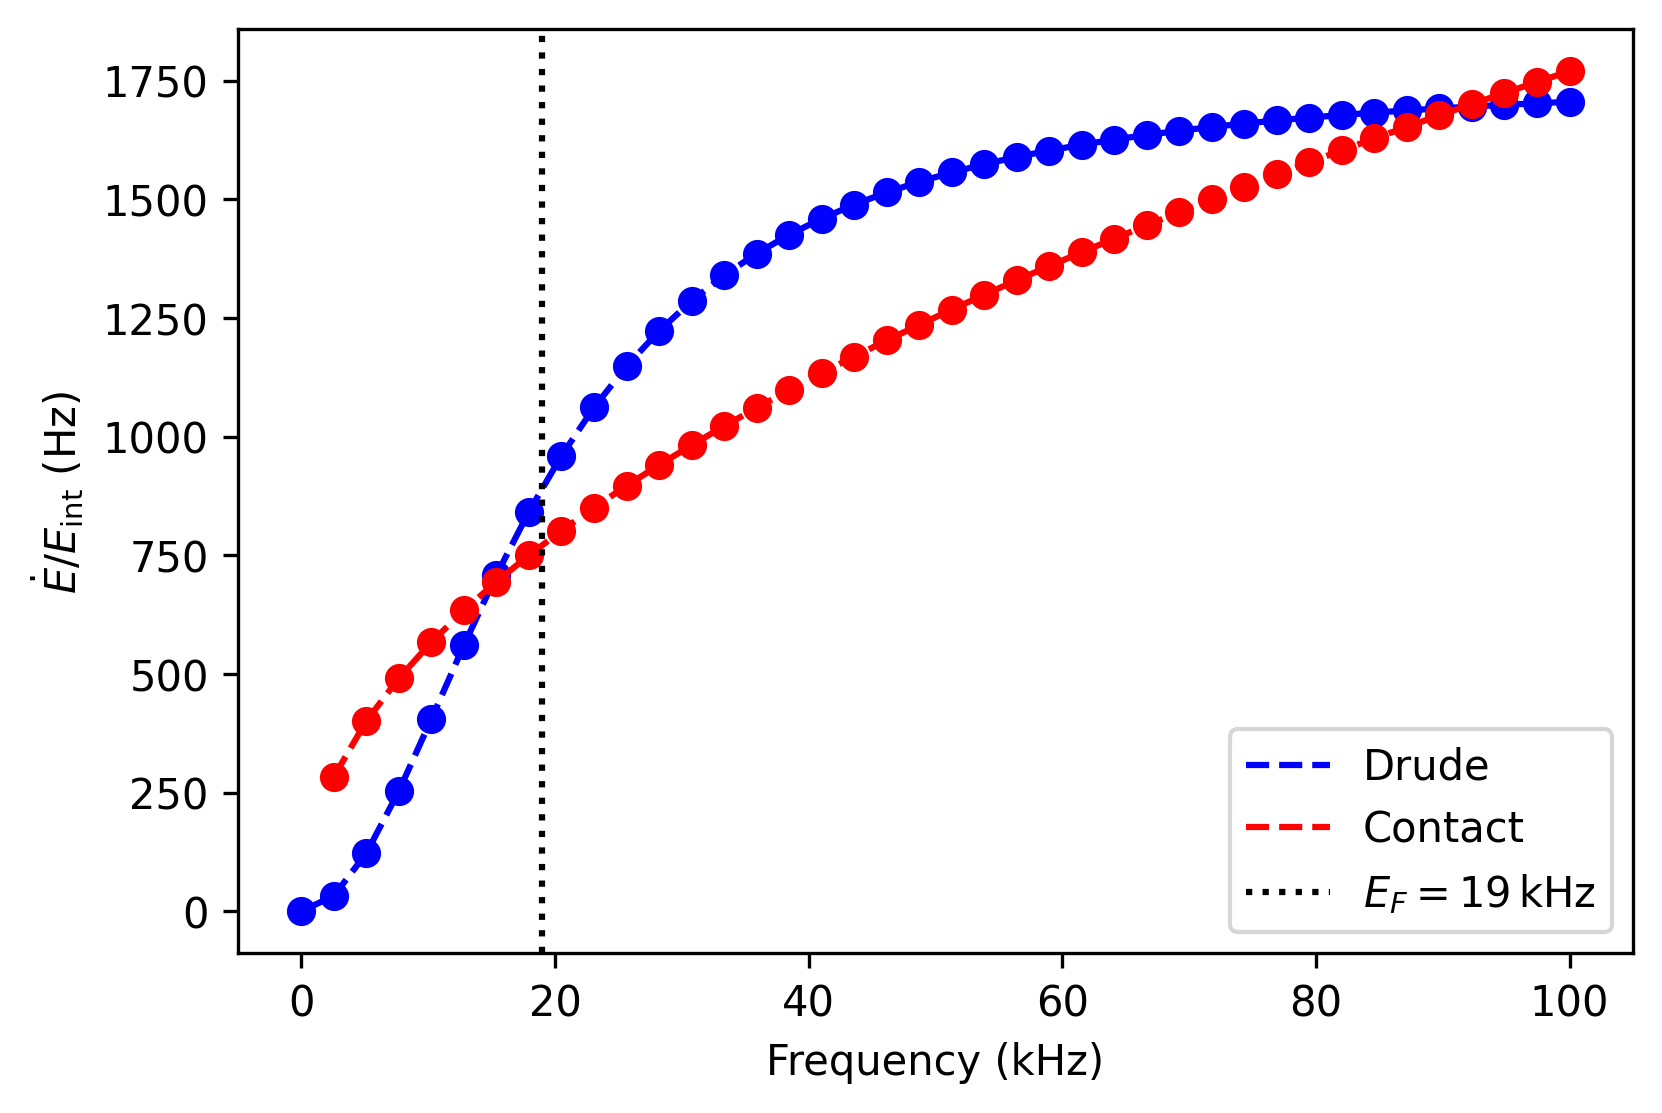

In [47]:
ToTF = 0.58
EF = 19e3
barnu = 305

TUG = TrappedUnitaryGas(ToTF=ToTF, EF=EF, barnu=barnu)

TUG.modulate_field(np.linspace(0, 100e3, 40))

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Epot, 'b--', label='Drude')
plt.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Epot, 'o', color='b', markersize=6)

plt.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Epot, 'r--', label='Contact')
plt.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Epot, 'o', color='r', markersize=6)

plt.xlabel('Frequency (kHz)')
plt.ylabel(r'$\dot{E}/E_\mathrm{int}$ (Hz)')

plt.axvline(x=TUG.EF/1e3, color='k', linestyle=':', label=r'$E_F = 19\,$kHz')

plt.legend()

plt.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

plt.show()